# OPM-MEG Tutorials in OSL: Pre-Processing

### Dataset overview
- Collected from the **Oxford OPM-MEG Lab**, December 2024
- One session, one run of data  
- **Cerca Magnetics Neuro-1 QZFM OPM system**
- **192 channels** total (64 sensor locations)  
- Each sensor has **X, Y, Z** channels corresponding to its sensitive orientation  


<img src="20250107_12_27_06_01.jpg" style="width:30%;">

### ⚙️ Software requirements

These tutorials rely on **homogeneous field correction**  
(Tierney et al., 2021), which is only available in:

- **`MNE` ≥ 0.18**
- **`osl-ephys` ≥ 0.24**

Please ensure your environment is up to date before continuing.

## The Four-Motor Task

The participant hears an **audio cue** instructing them to move one of the following:

- ✋ Right arm  
- 🤚 Left arm  
- 🦵 Right leg  
- 🦿 Left leg  

Each movement is performed for **4 seconds**, followed by a **variable inter-stimulus interval**.



In [1]:
# We start by importing the relevant packages
import osl_ephys
import numpy as np
import mne
import glob
import yaml
import os
import matplotlib.pyplot as plt

print('MNE version: {}'.format(mne.__version__))

# Print OSL-Ephys version
try:
    print('OSL-Ephys version: {}'.format(osl_ephys.__version__))
except AttributeError:
    from importlib.metadata import version
    print('OSL-Ephys version: {}'.format(version('osl-ephys')))

# Set global font to Open Sans
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12  # Adjust font size as desired

%matplotlib inline

Using matplotlib as 2D backend.
MNE version: 1.11.0
OSL-Ephys version: 2.4.dev0


## Specify Subject, Session and Task

In [2]:
subject  = '001'
ses      = '001'
task     = 'fourMotor'
run      = '001'

data_dir = os.path.join(os.getcwd(),'study-FourMotorOPM')

## Load in the Data

In [3]:
filename = os.path.join(
    data_dir,
    'BIDS',
    f'sub-{subject}',
    f'ses-{ses}',
    'meg',
    f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_meg.fif'
)

raw = mne.io.read_raw_fif(filename, preload=True)


Opening raw data file /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_meg.fif...
    Range : 0 ... 2198783 =      0.000 ...  1465.855 secs
Ready.
Reading 0 ... 2198783  =      0.000 ...  1465.855 secs...


## Plot Sensor Layout and Headshape in 3D

In [4]:
# Plot the sensors to check they are in the right orientation
fig = mne.viz.plot_alignment(raw.info,dig=True)

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Getting helmet for system unknown (derived from 192 MEG channel locations)
Channel types::	mag: 192


Note, the very dense headshape we get from the 3D scanner.

![png](01_OPM_preprocessing/screenshot_sensors_headshape.png)

## Plot the Raw Data

### Note the very large low-frequency artefacts when the person is moving (this is normal!)

Setting up band-pass filter from 1 - 1.1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 110.00 Hz: -6.02, -6.02 dB



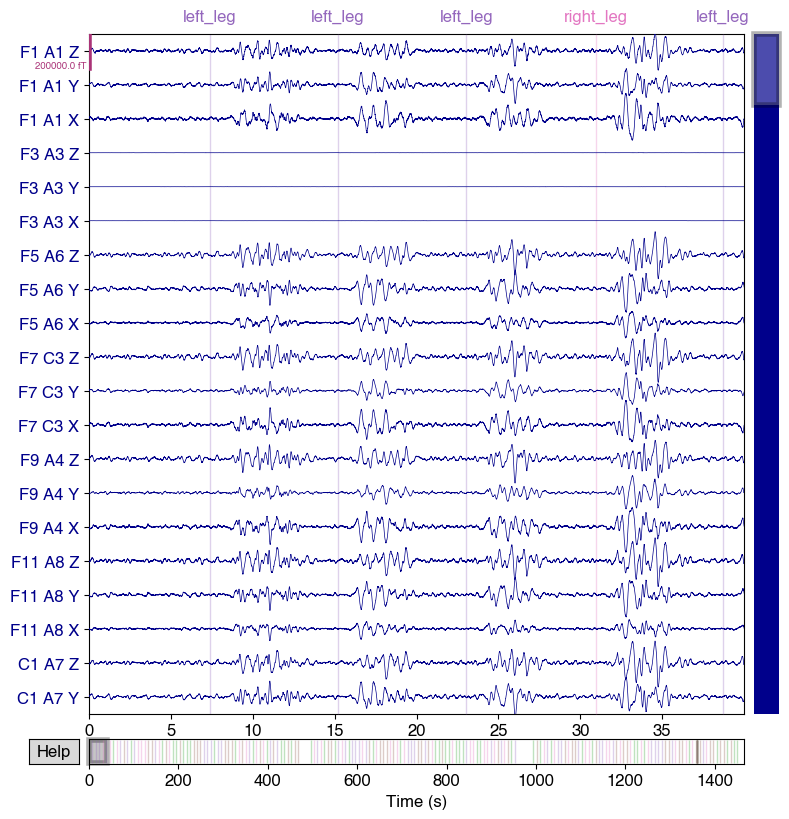

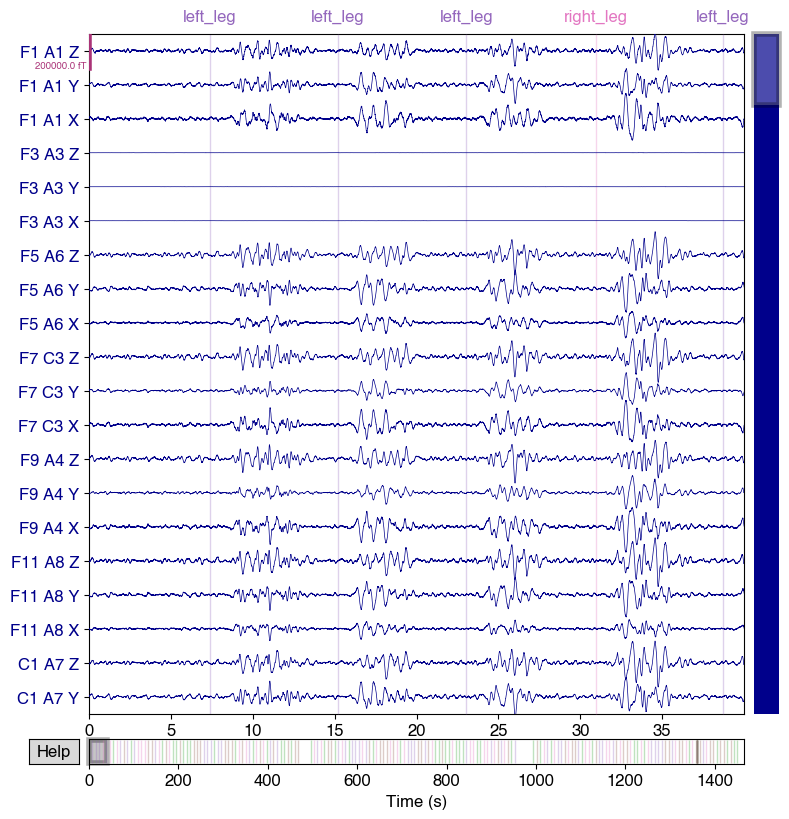

In [5]:
# Plot the first 10s of raw data
raw.plot(highpass=1,
         lowpass=110.0,scalings = {'mag' : 1e-10},
         duration=40,butterfly=False,picks='mag')

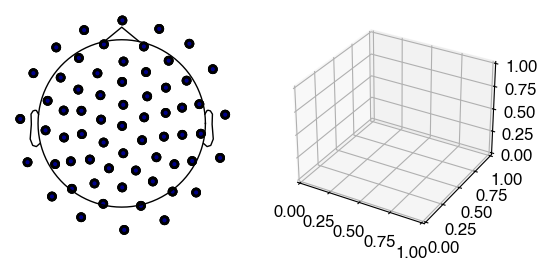

In [6]:
fig = plt.figure()
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection="3d")
raw.plot_sensors(ch_type="mag", axes=ax2d)
raw.plot_sensors(ch_type="mag", axes=ax3d, kind="3d")
ax3d.view_init(azim=70, elev=15)

## Add in channels we know are bad - H6, A3, G8

In [7]:
# Add in channels we know are bad
import re

pattern = r'\b(H6|A3|G8) [XYZ]\b' # Modify accordingly
matched_channels = [ch for ch in raw.info.ch_names if re.search(pattern, ch)]

raw.info['bads'].extend(matched_channels)

## Downsample the data to 300Hz

In [8]:
x = raw.copy().pick(picks=['mag'])
raw_downsampled = x.copy().resample(sfreq=300)

## Mark Bad Segments Based on Kurtosis

#### This seems to work well for the square wave jumps present in this particular dataset (now fixed)

In [9]:
from osl_ephys.preprocessing.osl_wrappers import bad_segments

raw_downsampled = bad_segments(
    raw_downsampled,
    picks='mag',
    segment_len=300,
    significance_level=0.05,
    metric='kurtosis',
    channel_wise = False
)

Setting up high-pass filter at 2 Hz

IIR filter parameters
---------------------
Butterworth highpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 2.00 Hz: -6.02 dB



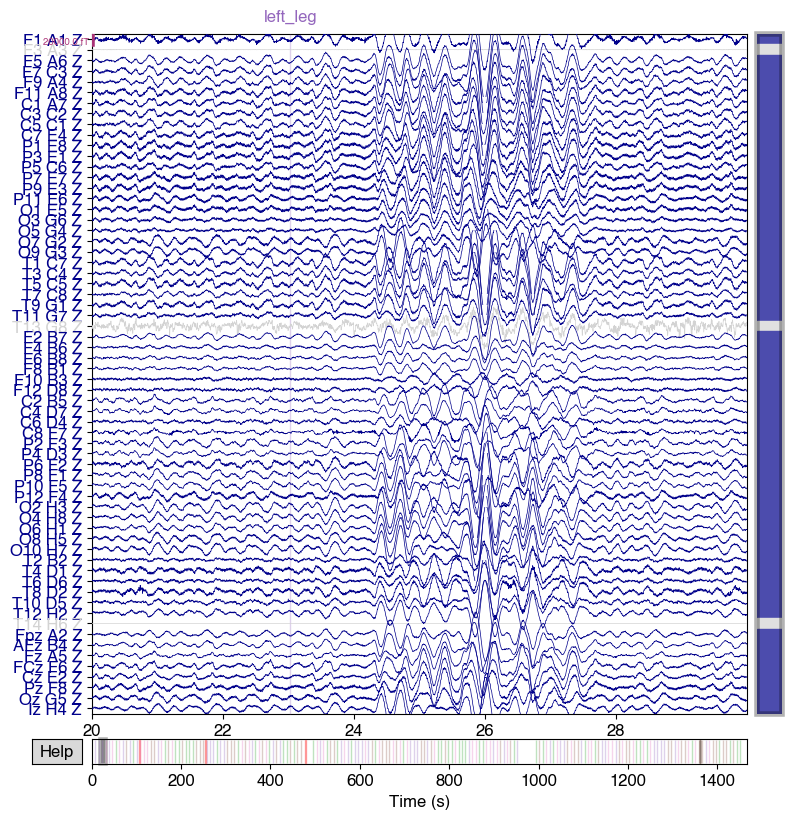

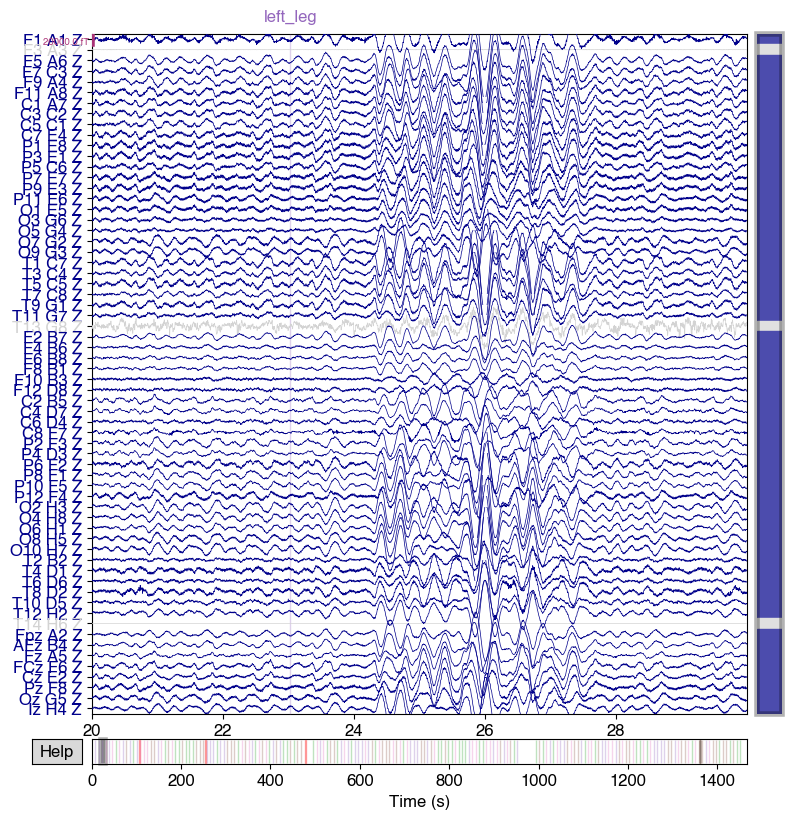

In [10]:
Z_picks = mne.pick_channels_regexp(raw_downsampled.info['ch_names'], regexp=r".*Z$")
raw_downsampled.plot(start=20,duration=10,picks=Z_picks,n_channels=64,highpass=2.0,
           butterfly=False,scalings = {'mag' : 1e-11})

## Plot the Power Spectral Density (PSD)

### Note we have some bad channels!

Setting 1200 of 439757 (0.27%) samples to NaN, retaining 438557 (99.73%) samples.
Effective window size : 6.667 (s)
Plotting power spectral density (dB=True).


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77359/4116602915.py:4: UserWarning: Infinite value in PSD for channels T14 H6 Z, T14 H6 Y.
These channels might be dead.
  fig = psd.plot()  # This now returns a figure
/opt/homebrew/Caskroom/mambaforge/base/envs/osle/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


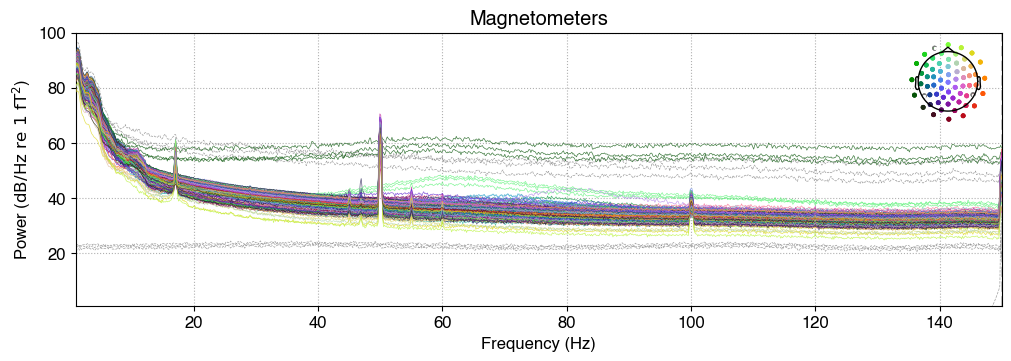

In [11]:
psd = raw_downsampled.compute_psd(fmin=1, fmax=150, n_fft=2000,reject_by_annotation=True)

# Plot the PSD
fig = psd.plot()  # This now returns a figure

# Get the axis object from the figure
ax = fig.axes[0]  # Since psd.plot() returns an array, we need to index into the first axis

# # Set the y-axis limits
ax.set_ylim(1, 100)

plt.show()

## Detect Bad Chans from the PSD using GESD

Generalized Extreme Studentized Deviate (GESD) is a statistical method for finding outlier channels in MEG data. When applied to power spectral density measures it looks for sensors whose power is much higher or lower than the rest of the array. The method works by identifying the most extreme channel testing whether it is unlikely to occur by chance and then repeating this process after removing it. This makes GESD well suited for automated bad channel detection in OPM-MEG because it can reliably flag noisy or malfunctioning sensors without requiring the number of bad channels to be set in advance.

In [12]:
from osl_ephys.preprocessing.osl_wrappers import detect_bad_channels_psd

# Example usage
bad_channels = detect_bad_channels_psd(raw_downsampled, fmin=10, fmax=80, alpha=0.05)
print("Detected bad channels:", bad_channels)


Detected bad channels: ['F1 A1 Z', 'F1 A1 Y', 'T11 G7 Z', 'T11 G7 Y', 'T11 G7 X']


### Now we can remove the bad channels

Setting 1200 of 439757 (0.27%) samples to NaN, retaining 438557 (99.73%) samples.
Effective window size : 10.000 (s)
Plotting power spectral density (dB=True).


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77359/1096303030.py:8: UserWarning: Infinite value in PSD for channels T14 H6 Z, T14 H6 Y.
These channels might be dead.
  fig = psd.plot()  # This now returns a figure
/opt/homebrew/Caskroom/mambaforge/base/envs/osle/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


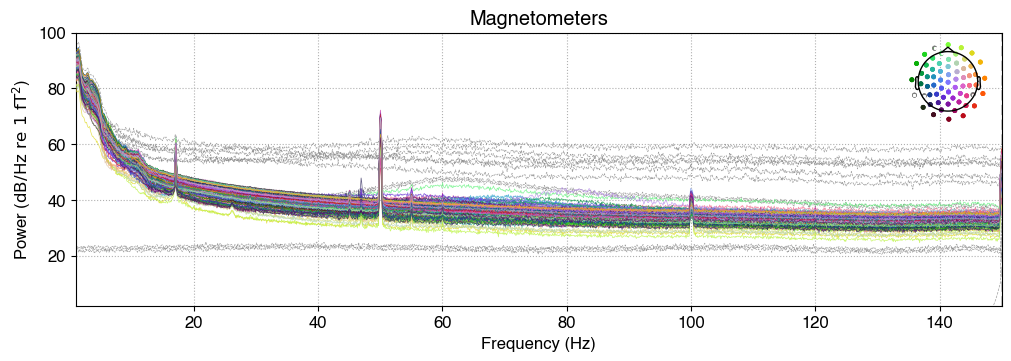

In [13]:
%matplotlib inline

# Add these channels as bad
raw_downsampled.info['bads'].extend(bad_channels)
psd = raw_downsampled.compute_psd(fmin=1, fmax=150, n_fft=3000,reject_by_annotation=True)

# Plot the PSD
fig = psd.plot()  # This now returns a figure
# Get the axis object from the figure
ax = fig.axes[0]  # Since psd.plot() returns an array, we need to index into the first axis
# # Set the y-axis limits
ax.set_ylim(2, 100)
plt.show()

## Find Events (trial onsets)

In [14]:
import os
import numpy as np
import mne

# Annotation labels to look for (combined into a regex)
pattern_list = ['left_arm', 'left_leg', 'right_arm', 'right_leg']
pattern = '|'.join(pattern_list)
print(f"Extracting events for: {pattern_list}")

# Extract events from annotations using the regex pattern
events, event_ids = mne.events_from_annotations(
    raw_downsampled,
    regexp=pattern
)

print(f"Number of events found: {len(events)}")
print(f"Event ID mapping: {event_ids}")

# Create BIDS derivatives directory for events
events_dir = os.path.join(
    data_dir, 'BIDS', 'derivatives', 'event',
    f'sub-{subject}', f'ses-{ses}', 'meg'
)
os.makedirs(events_dir, exist_ok=True)
print(f"Events directory created/exists: {events_dir}")

# Save the events array
events_file = os.path.join(
    events_dir,
    f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_events.npy'
)
np.save(events_file, events)
print(f"Events saved to: {events_file}\n")

Extracting events for: ['left_arm', 'left_leg', 'right_arm', 'right_leg']
Used Annotations descriptions: [np.str_('left_arm'), np.str_('left_leg'), np.str_('right_arm'), np.str_('right_leg')]
Number of events found: 182
Event ID mapping: {np.str_('left_arm'): 1, np.str_('left_leg'): 2, np.str_('right_arm'): 3, np.str_('right_leg'): 4}
Events directory created/exists: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/event/sub-001/ses-001/meg
Events saved to: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/event/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_events.npy



## Homogenous Field Correction (HFC) - Order 1 and 2

Homogeneous Field Correction (HFC) estimates and subtracts the spatially homogeneous component of the magnetic field from OPM recordings, suppressing environmental and movement-related noise while retaining neural signal.

Specify order = 1 for homogenous field or = 2 to also include gradients

3 projection items deactivated
8 projection items deactivated
Setting 1200 of 439757 (0.27%) samples to NaN, retaining 438557 (99.73%) samples.
Effective window size : 6.667 (s)
Setting 1200 of 439757 (0.27%) samples to NaN, retaining 438557 (99.73%) samples.
Effective window size : 6.667 (s)
Setting 1200 of 439757 (0.27%) samples to NaN, retaining 438557 (99.73%) samples.
Effective window size : 6.667 (s)
Plotting power spectral density (dB=True).


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77359/412897256.py:34: UserWarning: Infinite value in PSD for channels T14 H6 Z, T14 H6 Y.
These channels might be dead.
  fig = psd_HFC2.plot()  # This now returns a figure
/opt/homebrew/Caskroom/mambaforge/base/envs/osle/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


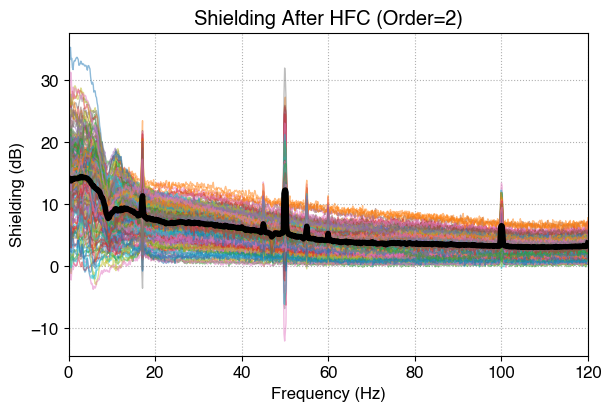

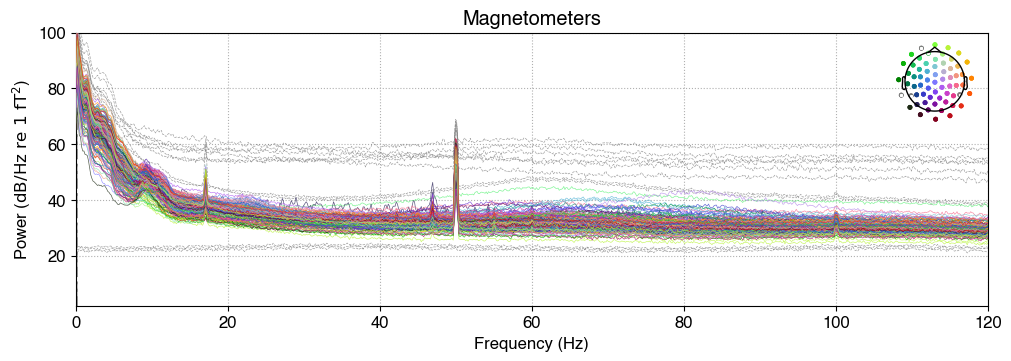

In [15]:
# Compute projections and apply them
projs1 = mne.preprocessing.compute_proj_hfc(raw_downsampled.info, order=1)
raw_hfc1 = raw_downsampled.copy().add_proj(projs1).apply_proj(verbose="error")

projs2 = mne.preprocessing.compute_proj_hfc(raw_downsampled.info, order=2)
raw_hfc2 = raw_downsampled.copy().add_proj(projs2).apply_proj(verbose="error")

# Compute PSDs
psd      = raw_downsampled.compute_psd(fmin=0, fmax=120, picks='mag', n_fft=2000)
psd_HFC1 = raw_hfc1.compute_psd(fmin=0, fmax=120, picks='mag', n_fft=2000)
psd_HFC2 = raw_hfc2.compute_psd(fmin=0, fmax=120, picks='mag', n_fft=2000)

# Extract data and freqs
psd_raw_data, freqs = psd.get_data(return_freqs=True)
psd_hfc1_data, _    = psd_HFC1.get_data(return_freqs=True)
psd_hfc2_data, _    = psd_HFC2.get_data(return_freqs=True)

# Compute shielding in dB (raw vs HFC2)
shielding = 10 * np.log10(psd_raw_data / psd_hfc2_data)

# --- Plot shielding ---
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.plot(freqs, shielding.T, lw=1, alpha=0.5)                  # all channels
ax.plot(freqs, shielding.mean(axis=0), lw=4, alpha=1, color='black')  # mean
ax.grid(True, ls=":")
ax.set(
    xlim=(0, 120),
    title="Shielding After HFC (Order=2)",
    xlabel="Frequency (Hz)",
    ylabel="Shielding (dB)",
)

# --- Plot PSD after HFC (Order=2) ---
fig = psd_HFC2.plot()  # This now returns a figure
ax = fig.axes[0]  # Since psd.plot() returns an array, we need to index into the first axis
ax.set_ylim(2, 100)
plt.show()

### Band-Pass using a Butterworth filter (2-50 Hz) and Notch Filter (50, 100 Hz)

In [16]:
# BP Filter
raw_bp = raw_hfc2.copy().filter(
    l_freq=2,
    h_freq=50,
    method='iir',                # use IIR (Butterworth)
    iir_params=dict(ftype='butter', order=4),  # 4th-order Butterworth
    verbose=True
)

# Notch Filter
freqs = (50, 100)
raw_notch = raw_bp.copy().notch_filter(freqs=freqs, picks='mag',notch_widths=2)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 2 - 50 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 2.00, 50.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1981 samples (6.603 s)



## Save the Intermediate Data

In [19]:
import os

# Directory where the pre-ICA MEG file will be saved (BIDS-style derivatives)
output_dir = os.path.join(data_dir,
    "BIDS", "derivatives", "preprocessing",
    f"sub-{subject}", f"ses-{ses}", "meg"
)

# Output filename for the pre-ICA cleaned data
output_file = f"sub-{subject}_ses-{ses}_task-{task}_run-{run}_preICA.fif"

# Create the output directory if it does not already exist
os.makedirs(output_dir, exist_ok=True)

# Full path to the output file
output_path = os.path.join(output_dir, output_file)

# Save the Raw object to disk
raw_notch.save(output_path, overwrite=True)

print(f"Pre-ICA data saved to: {output_path}")

Writing /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_preICA.fif


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77359/2005756184.py:19: RuntimeWarning: This filename (/Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_preICA.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_notch.save(output_path, overwrite=True)


Closing /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_preICA.fif
[done]
Pre-ICA data saved to: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_preICA.fif


## ICA

The ICA model is configured using the following parameters:

- **`n_components = 60`**  
  Controls the number of independent components to estimate. For MEG data, this is often set to a value lower than the total number of sensors to improve numerical stability while still capturing the dominant structure of the data.

- **`random_state = 34`**  
  Fixes the random seed used during ICA initialization. This ensures the decomposition is reproducible across runs, which is important for debugging and for comparisons across subjects or sessions.

- **`max_iter = 800`**  
  Specifies the maximum number of iterations allowed for the algorithm to converge. Higher values can help ensure convergence when working with noisy MEG or OPM-MEG recordings.

- **`method = "fastica"`**  
  Selects the FastICA algorithm, which is computationally efficient and widely used in MEG preprocessing pipelines. You could use a fancier ICA variant, but in my experience this suffices 99% of the time.



In [ ]:
from mne.preprocessing import ICA
from mne.viz import plot_topomap
import numpy as np

# Compute ICA on all channels (use raw_notch as input)
ica = ICA(n_components=60, random_state=34, max_iter=800,method='fastica')
ica.fit(raw_notch)  # Fit ICA on all channels

Fitting ICA to data using 178 channels (please be patient, this may take a while)
Omitting 1200 of 439757 (0.27%) samples, retaining 438557 (99.73%) samples.
    Applying projection operator with 8 vectors (pre-whitener computation)
    Applying projection operator with 8 vectors (pre-whitener application)
Selecting by number: 60 components
    Applying projection operator with 8 vectors (pre-whitener application)
Fitting ICA took 17.1s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=800
Fit,57 iterations on raw data (438557 samples)
ICA components,60
Available PCA components,178
Channel types,mag
ICA components marked for exclusion,—


### Plot ICA sources - the default osl-ephys plotter cannot only plot the Z-orientation

In [22]:
%matplotlib qt

browser = ica.plot_sources(raw_notch, show_scrollbars=False)
browser.show()  # Show it if not already visible

# Access the underlying Qt window and resize
qt_window = browser.canvas.parent()
qt_window.resize(1200, 600)

from mne.viz import plot_topomap
import math

def plot_ica_topomaps_Z(raw_notch, ica, batch_size=10, colormap='RdBu_r'):
    """
    Plot ICA components as topomaps for selected good Z channels, displaying them in batches.
    """

    # Get good channels
    all_channels = raw_notch.info['ch_names']
    bad_channels = raw_notch.info['bads']
    good_channels = [ch for ch in all_channels if ch not in bad_channels]

    # Get channels matching the regex pattern
    Z_picks = mne.pick_channels_regexp(all_channels, regexp=r".*Z$")
    Z_channels = [all_channels[i] for i in Z_picks]

    # Keep only good Z channels
    Z_good_channels = [ch for ch in Z_channels if ch in good_channels]

    # Get ICA channel names
    ica_channels = ica.info['ch_names']

    # Indices of Z good channels in ICA
    Z_good_ica_picks = [ica_channels.index(ch) for ch in Z_good_channels]

    # Use only info (no data copy) for plotting
    raw_info_Z = raw_notch.copy().pick_channels(Z_good_channels).info

    # Get ICA components
    ica_data = ica.get_components()
    num_components = ica.n_components_

    # Suppress interactive rendering
    plt.ioff()

    # Loop through components in batches
    for i in range(0, num_components, batch_size):
        num_subplots = min(batch_size, num_components - i)
        rows = int(math.ceil(num_subplots / 6))  # 6 columns
        cols = 6

        fig, axes = plt.subplots(rows, cols, figsize=(7, 12))
        axes = axes.ravel()

        for idx, comp in enumerate(range(i, min(i + batch_size, num_components))):
            comp_data = ica_data[Z_good_ica_picks, comp]
            ax = axes[idx]

            plot_topomap(comp_data, raw_info_Z, axes=ax, show=False,
                         size=3, cmap=colormap)

            ax.text(-0.2, 0.5, f'{comp}', transform=ax.transAxes,
                    fontsize=6, va='center', ha='right')

        # Hide unused axes
        for j in range(idx + 1, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()

    # Render all figures at once
    plt.show()
    plt.ion()

plot_ica_topomaps_Z(raw_notch, ica, batch_size=60, colormap='Spectral_r')

    Applying projection operator with 8 vectors (pre-whitener application)
Creating RawArray with float64 data, n_channels=60, n_times=439757
    Range : 0 ... 439756 =      0.000 ...  1465.853 secs
Ready.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Component 40 corresponds to an eye-blink artefact and 59 is a horizontal eye-movement artefact (note, the frontal topography of the component and sharper jumps)

![png](./01_OPM_preprocessing/ica1.png)

![png](./01_OPM_preprocessing/ica2.png)

### Manually specify the components to exclude

In [23]:
ica.exclude = [40,59]  # indices chosen based on various plots above

# # Remove bad components from the data
clean = ica.apply(raw_notch.copy())

Applying ICA to Raw instance
    Applying projection operator with 8 vectors (pre-whitener application)
    Transforming to ICA space (60 components)
    Zeroing out 2 ICA components
    Projecting back using 178 PCA components


### Plot again

In [ ]:
%matplotlib inline
Z_picks = mne.pick_channels_regexp(clean.info['ch_names'], regexp=r".*Z$")
clean.plot(start=20,duration=10,picks=Z_picks,n_channels=64,
           butterfly=False,scalings = {'mag' : 1e-11})
# plt.savefig('clean_plot.png', dpi=300, bbox_inches='tight')

## Save the Clean Data

In [25]:
# Directory where the cleaned MEG data will be saved (BIDS derivatives)
output_dir = os.path.join(
    data_dir,
    "BIDS", "derivatives", "preprocessing",
    f"sub-{subject}", f"ses-{ses}", "meg"
)

# Filename for the cleaned dataset
output_file = f"sub-{subject}_ses-{ses}_task-{task}_run-{run}_clean.fif"

# Create the output directory if it does not already exist
os.makedirs(output_dir, exist_ok=True)

# Full path to the output file
output_path = os.path.join(output_dir, output_file)

# Save the cleaned Raw object to disk
clean.save(output_path, overwrite=True)

print(f"Cleaned data saved to: {output_path}")

Writing /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_77359/256001756.py:18: RuntimeWarning: This filename (/Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  clean.save(output_path, overwrite=True)


Closing /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif
[done]
Cleaned data saved to: /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-001/ses-001/meg/sub-001_ses-001_task-fourMotor_run-001_clean.fif
